<a href="https://colab.research.google.com/github/YaroslavTrusov/python-ai-template-Yaroslav_Trusov/blob/main/notebooks/week3_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Week 3: Visualization — Визуализация

## 📥 [0] Подготовка данных: клонирование репозитория и загрузка CSV

**Что делаем:**
- Клонируем GitHub-репозиторий курса в Google Colab
- Загружаем CSV-файл `planes.csv`, `engines.csv`, `engine_manufacturers.csv`
- Очищаем столбцы: переименовываем URL Wikidata в `URL`, переименовываем `*Label` → короткие имена


In [2]:
# 🐱 Шаг 1. Клонируем репозиторий в Colab

import os
import pandas as pd
from IPython.display import display

repo = "python-ai-template-Yaroslav_Trusov"
repo_path = f"/content/{repo}"  # абсолютный путь — не зависит от cwd

if not os.path.exists(repo_path):          # всегда проверяет /content/python-ai-template
    !git clone -q https://github.com/YaroslavTrusov/python-ai-template-Yaroslav_Trusov

if os.getcwd() != repo_path:               # точное сравнение, не endswith
    %cd {repo_path}

print("✅ Репозиторий готов, теперь мы работаем внутри папки", repo)

# Шаг 2: Загружаем CSV-файлы
df_planes = pd.read_csv("data/planes.csv")
df_engines = pd.read_csv("data/engines.csv")
df_engine_manufacturers = pd.read_csv("data/engine_manufacturers.csv")
print(f"📊 Загружено строк в df_planes (самолеты): {len(df_planes)}")
print(f"📊 Загружено строк в df_engines (двигатели): {len(df_engines)}\n")
print(f"📊 Загружено строк в df_engine_manufacturers (производители самолетов): {len(df_engine_manufacturers)}")

# 🧹 ШАГ 3: Очистка и переименование столбцов

# ============================================================================
# 1️⃣ df_planes: Самолёты
# ============================================================================
print("=" * 60)
print("✈️ Обработка df_planes (самолёты)")
print("=" * 60)

# Переименование столбцов (с проверкой наличия)
if "aircraftLabel" in df_planes.columns:
    df_planes = df_planes.rename(columns={
        "aircraft": "aircraftURL",
        "aircraftLabel": "aircraft",
        "engine": "engineURL",
        "engineLabel": "engine",
        "maxAltitude": "altitude",
        "totalProduced": "produced",
    })
    print("✅ Столбцы переименованы")
else:
    print("⏭️ Столбцы уже переименованы, пропускаем")

# Проверка заполненности ДО очистки (OPTIONAL-поля)
print("\n📊 Заполненность данных ДО очистки:")
optional_planes = ["price", "altitude", "produced"]
for col in optional_planes:
    if col in df_planes.columns:
        fill_rate = df_planes[col].notna().mean()
        status = "⚠️ НИЗКАЯ" if fill_rate < 0.15 else "✅"
        print(f"   {status} {col:12s}: {fill_rate:6.2%} ({df_planes[col].notna().sum()} из {len(df_planes)})")

# 🔧 Очистка числовых полей (ИСПРАВЛЕНИЕ: прямой astype на Series)
print("\n🔧 Очистка числовых полей:")
for col in ["altitude", "price", "produced"]:
    if col in df_planes.columns:
        if df_planes[col].dtype not in ['Int64', 'int64']:
            # 🔧 ИСПРАВЛЕНИЕ: convert_dtypes() автоматически выбирает Int64
            df_planes[col] = pd.to_numeric(df_planes[col], errors="coerce").convert_dtypes()
            print(f"   ✅ {col:12s}: преобразован в {df_planes[col].dtype} (NaN сохранён)")
        else:
            print(f"   ⏭️ {col:12s}: уже числовой, пропускаем")

# Проверка заполненности ПОСЛЕ очистки
print("\n📊 Заполненность данных ПОСЛЕ очистки:")
for col in optional_planes:
    if col in df_planes.columns:
        fill_rate = df_planes[col].notna().mean()
        print(f"   {col:12s}: {fill_rate:6.2%}")

# Документирование «длинного формата»
print(f"\n📏 Структура данных:")
print(f"   Уникальных самолётов (aircraftURL): {df_planes['aircraftURL'].nunique()}")
print(f"   Всего строк: {len(df_planes)}")
print(f"   → Среднее строк на самолёт: {len(df_planes)/df_planes['aircraftURL'].nunique():.2f}")
if len(df_planes) > df_planes['aircraftURL'].nunique() * 1.5:
    print("   ⚠️ Данные в «длинном формате» — один самолёт имеет несколько записей")


# ============================================================================
# 2️⃣ df_engines: Двигатели
# ============================================================================
print("\n" + "=" * 60)
print("🔧 Обработка df_engines (двигатели)")
print("=" * 60)

# Переименование столбцов
if "engineLabel" in df_engines.columns:
    df_engines = df_engines.rename(columns={
        "engine": "engineURL",
        "engineLabel": "engine",
        "manufacturer": "manufacturerURL",
        "manufacturerLabel": "manufacturer",
    })
    print("✅ Столбцы переименованы")
else:
    print("⏭️ Столбцы уже переименованы, пропускаем")

# Проверка заполненности ДО очистки
print("\n📊 Заполненность данных ДО очистки:")
optional_engines = ["cylinders", "cooling", "power"]
for col in optional_engines:
    if col in df_engines.columns:
        fill_rate = df_engines[col].notna().mean()
        status = "⚠️ НИЗКАЯ" if fill_rate < 0.15 else "✅"
        print(f"   {status} {col:12s}: {fill_rate:6.2%} ({df_engines[col].notna().sum()} из {len(df_engines)})")

# 🔧 Очистка числовых полей (ИСПРАВЛЕНИЕ)
print("\n🔧 Очистка числовых полей:")
for col in ["cylinders", "power"]:
    if col in df_engines.columns:
        if df_engines[col].dtype not in ['Int64', 'int64']:
            df_engines[col] = pd.to_numeric(df_engines[col], errors="coerce").convert_dtypes()
            print(f"   ✅ {col:12s}: преобразован в {df_engines[col].dtype} (NaN сохранён)")
        else:
            print(f"   ⏭️ {col:12s}: уже числовой, пропускаем")

# Строковые поля (cooling) — привести к нижнему регистру
if "cooling" in df_engines.columns:
    df_engines["cooling"] = df_engines["cooling"].str.lower().str.strip()
    print("   ✅ cooling: приведён к нижнему регистру")

# Проверка заполненности ПОСЛЕ очистки
print("\n📊 Заполненность данных ПОСЛЕ очистки:")
for col in optional_engines:
    if col in df_engines.columns:
        fill_rate = df_engines[col].notna().mean()
        print(f"   {col:12s}: {fill_rate:6.2%}")

# Документирование структуры
print(f"\n📏 Структура данных:")
print(f"   Уникальных двигателей (engineURL): {df_engines['engineURL'].nunique()}")
print(f"   Всего строк: {len(df_engines)}")
print(f"   → Среднее строк на двигатель: {len(df_engines)/df_engines['engineURL'].nunique():.2f}")


# ============================================================================
# 3️⃣ df_engine_manufacturers: Производители двигателей
# ============================================================================
print("\n" + "=" * 60)
print("🏭 Обработка df_engine_manufacturers (производители)")
print("=" * 60)

# Переименование столбцов
if "manufacturerLabel" in df_engine_manufacturers.columns:
    df_engine_manufacturers = df_engine_manufacturers.rename(columns={
        "manufacturer": "manufacturerURL",
        "manufacturerLabel": "manufacturer",
        "countryLabel": "country",
        "headquartersLabel": "headquarters",
    })
    print("✅ Столбцы переименованы")
else:
    print("⏭️ Столбцы уже переименованы, пропускаем")

# Проверка заполненности ДО очистки
print("\n📊 Заполненность данных ДО очистки:")
optional_mfr = ["country", "headquarters", "coordinates", "founded"]
for col in optional_mfr:
    if col in df_engine_manufacturers.columns:
        fill_rate = df_engine_manufacturers[col].notna().mean()
        status = "⚠️ НИЗКАЯ" if fill_rate < 0.15 else "✅"
        print(f"   {status} {col:15s}: {fill_rate:6.2%} ({df_engine_manufacturers[col].notna().sum()} из {len(df_engine_manufacturers)})")

# 🔧 Очистка числовых полей (ИСПРАВЛЕНИЕ)
print("\n🔧 Очистка числовых полей:")
for col in ["founded"]:
    if col in df_engine_manufacturers.columns:
        if df_engine_manufacturers[col].dtype not in ['Int64', 'int64']:
            df_engine_manufacturers[col] = pd.to_numeric(df_engine_manufacturers[col], errors="coerce").convert_dtypes()
            print(f"   ✅ {col:15s}: преобразован в {df_engine_manufacturers[col].dtype} (NaN сохранён)")
        else:
            print(f"   ⏭️ {col:15s}: уже числовой, пропускаем")

# Строковые поля — привести к нижнему регистру
for col in ["country", "headquarters"]:
    if col in df_engine_manufacturers.columns:
        df_engine_manufacturers[col] = df_engine_manufacturers[col].str.lower().str.strip()
        print(f"   ✅ {col:15s}: приведён к нижнему регистру")

# Проверка заполненности ПОСЛЕ очистки
print("\n📊 Заполненность данных ПОСЛЕ очистки:")
for col in optional_mfr:
    if col in df_engine_manufacturers.columns:
        fill_rate = df_engine_manufacturers[col].notna().mean()
        print(f"   {col:15s}: {fill_rate:6.2%}")

# Документирование структуры
print(f"\n📏 Структура данных:")
print(f"   Уникальных производителей (manufacturerURL): {df_engine_manufacturers['manufacturerURL'].nunique()}")
print(f"   Всего строк: {len(df_engine_manufacturers)}")
print(f"   → Среднее строк на производителя: {len(df_engine_manufacturers)/df_engine_manufacturers['manufacturerURL'].nunique():.2f}")


# ============================================================================
# 📋 ИТОГОВАЯ ПРОВЕРКА
# ============================================================================
print("\n" + "=" * 60)
print("✅ ИТОГОВАЯ ПРОВЕРКА ВСЕХ ДАТАФРЕЙМОВ")
print("=" * 60)

summary_data = [
    ("df_planes", df_planes),
    ("df_engines", df_engines),
    ("df_engine_manufacturers", df_engine_manufacturers)
]

for df_name, df in summary_data:
    print(f"\n{df_name}:")
    print(f"   📊 Размер: {df.shape[0]:,} строк × {df.shape[1]} столбцов")
    url_cols = [c for c in df.columns if 'URL' in c]
    print(f"   🔑 URL-столбец: {url_cols[0] if url_cols else 'Не найден'}")
    print(f"   📋 Столбцы: {list(df.columns)}")

# Краткий обзор датасетов
def show_info(df, name, n=5):
    """Краткий обзор DataFrame: имя, размер, список столбцов и первые строки."""
    print(f"\n📊 {name}")
    print("Размер:", df.shape)
    print("Столбцы:", ", ".join(df.columns))
    print("\nПервые строки:")
    print(df.head(n))

# 🔍 Шаг 3. Обзор данных

show_info(df_planes, "Виды самолетов, двигателей, цена, максимальная высота и суммарное количество, произведенных самолетов (df_planes)")
print(df_planes[['altitude', 'price', 'produced']].describe())
show_info(df_engines, "Виды двигателей, используемых в самолётах, с обязательным производителем и страной (df_engines)")
print(df_engines[['cylinders']].describe())
show_info(df_engine_manufacturers, "Производители двигателей, используемых в самолётах, с метками страны и штаб-квартиры (df_engine_manufacturers)")

/content/python-ai-template-Yaroslav_Trusov
✅ Репозиторий готов, теперь мы работаем внутри папки python-ai-template-Yaroslav_Trusov
📊 Загружено строк в df_planes (самолеты): 1109
📊 Загружено строк в df_engines (двигатели): 1224

📊 Загружено строк в df_engine_manufacturers (производители самолетов): 309
✈️ Обработка df_planes (самолёты)
✅ Столбцы переименованы

📊 Заполненность данных ДО очистки:
   ⚠️ НИЗКАЯ price       :  2.52% (28 из 1109)
   ✅ altitude    : 45.72% (507 из 1109)
   ✅ produced    : 100.00% (1109 из 1109)

🔧 Очистка числовых полей:
   ✅ altitude    : преобразован в Float64 (NaN сохранён)
   ✅ price       : преобразован в Int64 (NaN сохранён)
   ⏭️ produced    : уже числовой, пропускаем

📊 Заполненность данных ПОСЛЕ очистки:
   price       :  2.52%
   altitude    : 45.72%
   produced    : 100.00%

📏 Структура данных:
   Уникальных самолётов (aircraftURL): 522
   Всего строк: 1109
   → Среднее строк на самолёт: 2.12
   ⚠️ Данные в «длинном формате» — один самолёт имеет не

In [3]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей для красивых графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

# Данные уже загружены и обработаны в ноутбуке
# Используем существующие df_planes, df_engines, df_engine_manufacturers

print("=" * 80)
print("🚀 ГЛУБОКИЙ АНАЛИЗ ДАННЫХ О САМОЛЕТАХ И ДВИГАТЕЛЯХ")
print("=" * 80)

🚀 ГЛУБОКИЙ АНАЛИЗ ДАННЫХ О САМОЛЕТАХ И ДВИГАТЕЛЯХ


## [1] Bar + Line Chart: The evolution of the aircraft industry

**Что показывает:** Эволюцию авиастроения (пик производства — Вторая мировая война, пик новых моделей — 1950-60-е (эпоха реактивной авиации)).

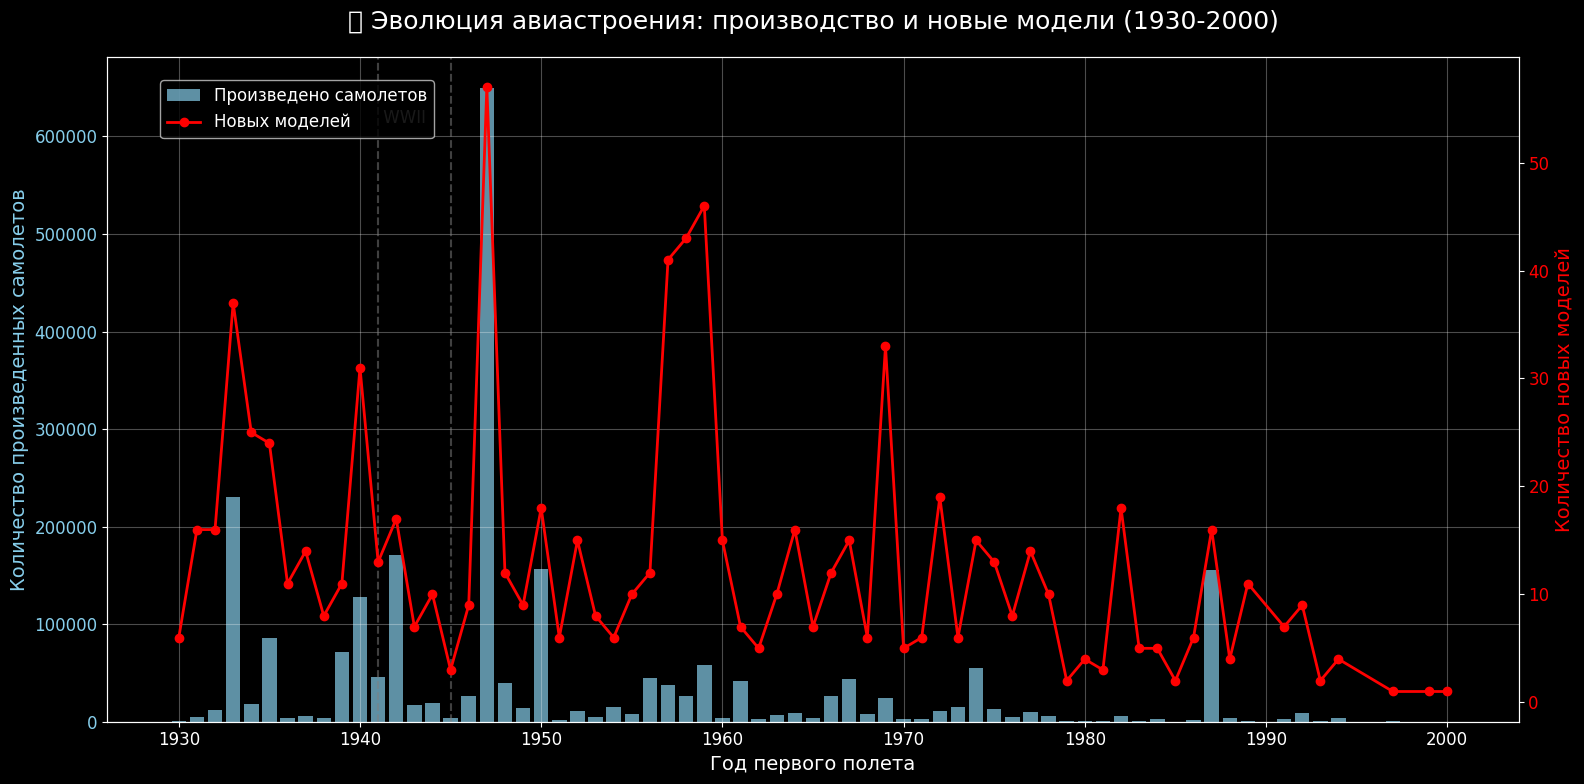

💡 Инсайт: Пик производства самолетов приходится на Вторую мировую войну (1941-1945), после чего наблюдается резкий спад. Количество новых моделей достигает максимума в 1950-60-е годы (эпоха реактивной авиации).


In [29]:
# Комбинированный график (Bar + Line) - Эволюция производства по годам
# Показывает динамику авиастроения

# Подготовка данных по годам
df_planes_years = df_planes.copy()
df_planes_years['year'] = pd.to_datetime(df_planes['firstFlight'], errors='coerce').dt.year
df_planes_years = df_planes_years.dropna(subset=['year', 'produced'])
df_planes_years['year'] = df_planes_years['year'].astype(int)

# Группируем по годам
yearly_production = df_planes_years.groupby('year').agg({
    'produced': 'sum',
    'aircraft': 'count'
}).reset_index()

# Фильтруем годы с 1930 по 2000 для лучшей читаемости
yearly_production = yearly_production[
    (yearly_production['year'] >= 1930) &
    (yearly_production['year'] <= 2000)
]

# Создаем комбинированный график
fig, ax1 = plt.subplots(figsize=(16, 8))

# Bar chart для количества произведенных самолетов
bars = ax1.bar(
    yearly_production['year'],
    yearly_production['produced'],
    alpha=0.7,
    color='skyblue',
    label='Произведено самолетов'
)
ax1.set_xlabel('Год первого полета', fontsize=14)
ax1.set_ylabel('Количество произведенных самолетов', fontsize=14, color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')

# Line chart для количества новых моделей
ax2 = ax1.twinx()
line = ax2.plot(
    yearly_production['year'],
    yearly_production['aircraft'],
    color='red',
    marker='o',
    linewidth=2,
    label='Новых моделей'
)
ax2.set_ylabel('Количество новых моделей', fontsize=14, color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Добавляем аннотации для ключевых событий
ax1.axvline(x=1941, color='gray', linestyle='--', alpha=0.5)
ax1.axvline(x=1945, color='gray', linestyle='--', alpha=0.5)
ax1.text(1941, ax1.get_ylim()[1]*0.9, ' WWII ', fontsize=12, color='gray')

ax1.set_title('📈 Эволюция авиастроения: производство и новые модели (1930-2000)',
              fontsize=18, pad=20)
ax1.grid(True, alpha=0.3)

# Добавляем легенду
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))

plt.tight_layout()
plt.show()

print("💡 Инсайт: Пик производства самолетов приходится на Вторую мировую войну (1941-1945), после чего наблюдается резкий спад. Количество новых моделей достигает максимума в 1950-60-е годы (эпоха реактивной авиации).")

In [5]:
# Импорт необходимых библиотек для географических визуализаций
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium
from folium.plugins import MarkerCluster, HeatMap
import geopandas as gpd
from shapely.geometry import Point
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("🌍 ГЕОГРАФИЧЕСКИЙ АНАЛИЗ ДАННЫХ О САМОЛЕТАХ И ДВИГАТЕЛЯХ")
print("=" * 80)

🌍 ГЕОГРАФИЧЕСКИЙ АНАЛИЗ ДАННЫХ О САМОЛЕТАХ И ДВИГАТЕЛЯХ




## 📊 [2] Choropleth map: Aircraft production by country

**Что показывает:**  
Топ стран по производству самолетов. Лидируют СССР/Россия, США и Великобритания.

In [28]:
# Choropleth карта мира - Производство самолетов по странам
# Показывает глобальное распределение авиастроения

# Подготовка данных: суммируем производство по странам
country_production = df_planes.groupby('countryLabel')['produced'].sum().reset_index()
country_production = country_production[country_production['countryLabel'].notna()]
country_production.columns = ['country', 'total_produced']

# Добавляем количество моделей
country_models = df_planes.groupby('countryLabel')['aircraft'].nunique().reset_index()
country_models.columns = ['country', 'num_models']
country_models = country_models[country_models['country'].notna()]

# Объединяем данные
country_stats = pd.merge(country_production, country_models, on='country')

# Нормализуем названия стран для plotly
country_stats['country'] = country_stats['country'].replace({
    'СССР': 'Russia',  # Plotly лучше понимает современные названия
    'США': 'United States',
    'Германия': 'Germany',
    'Франция': 'France',
    'Великобритания': 'United Kingdom',
    'Италия': 'Italy',
    'Япония': 'Japan',
    'Канада': 'Canada',
    'Швеция': 'Sweden',
    'Китай': 'China',
    'Польша': 'Poland',
    'Чехия': 'Czech Republic',
    'Нидерланды': 'Netherlands',
    'Израиль': 'Israel',
    'Бразилия': 'Brazil',
    'Индия': 'India',
    'Австралия': 'Australia',
    'Украина': 'Ukraine',
    'Швейцария': 'Switzerland',
    'Испания': 'Spain'
})

# Создаем choropleth карту
fig = px.choropleth(
    country_stats,
    locations='country',
    locationmode='country names',
    color='total_produced',
    hover_name='country',
    hover_data={
        'total_produced': ':,.0f',
        'num_models': True,
        'country': False
    },
    color_continuous_scale='Viridis',
    range_color=[0, country_stats['total_produced'].max()],
    title='🌍 Choropleth карта: Производство самолетов по странам',
    labels={'total_produced': 'Произведено самолетов', 'num_models': 'Количество моделей'}
)

fig.update_layout(
    width=1200,
    height=600,
    title_font_size=24,
    title_x=0.5,
    geo=dict(
        showframe=True,
        showcoastlines=True,
        projection_type='equirectangular',
        showland=True,
        landcolor='rgb(243, 243, 243)',
        countrycolor='rgb(204, 204, 204)'
    )
)

fig.show()

print("💡 Географический инсайт: Абсолютным лидером по производству самолетов является СССР/Россия (более 2 млн самолетов), за ним следуют США (≈400,000) и Великобритания. Европейские страны образуют плотный кластер высокого производства.")

💡 Географический инсайт: Абсолютным лидером по производству самолетов является СССР/Россия (более 2 млн самолетов), за ним следуют США (≈400,000) и Великобритания. Европейские страны образуют плотный кластер высокого производства.


In [7]:
# Импорт библиотек для продвинутого анализа
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import networkx as nx
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 12

print("=" * 80)
print("🔍 ПОИСК СКРЫТЫХ ПАТТЕРНОВ В ДАННЫХ О САМОЛЕТАХ")
print("=" * 80)

🔍 ПОИСК СКРЫТЫХ ПАТТЕРНОВ В ДАННЫХ О САМОЛЕТАХ



## 📊 [3] Parallel Coordinates: Engine analysis
**Что показывает:** Показывает связи между характеристиками двигателей разных стран.

**Когда использовать:** Для многомерный анализ двигателей.

In [9]:
# Parallel Coordinates - многомерный анализ двигателей
# Показывает связи между характеристиками двигателей разных стран

# Подготовка данных
df_parallel = df_engines.copy()
df_parallel = df_parallel.dropna(subset=['cylinders', 'countryLabel'])
df_parallel = df_parallel[df_parallel['cylinders'] > 0]

# Создаем числовые признаки
df_parallel['cylinders_normalized'] = df_parallel['cylinders']
df_parallel['has_cooling'] = df_parallel['fuelOrCoolantLabel'].notna().astype(int) * 10
df_parallel['has_based_on'] = df_parallel['basedOnLabel'].notna().astype(int) * 10

# Кодируем страну для цвета
country_codes = {country: i for i, country in enumerate(df_parallel['countryLabel'].unique())}
df_parallel['country_code'] = df_parallel['countryLabel'].map(country_codes)

# Берем топ-8 стран по количеству
top_countries_parallel = df_parallel['countryLabel'].value_counts().head(8).index
df_parallel_top = df_parallel[df_parallel['countryLabel'].isin(top_countries_parallel)]

# Создаем parallel coordinates plot
fig = go.Figure(data=
    go.Parcoords(
        line=dict(
            color=df_parallel_top['country_code'],
            colorscale='Viridis',
            showscale=True,
            colorbar=dict(
                title='Страна',
                tickvals=list(country_codes.values()),
                ticktext=list(country_codes.keys())
            )
        ),
        dimensions=[
            dict(
                range=[df_parallel_top['cylinders'].min(), df_parallel_top['cylinders'].max()],
                label='Цилиндры',
                values=df_parallel_top['cylinders']
            ),
            dict(
                range=[0, 10],
                label='Наличие охлаждения',
                values=df_parallel_top['has_cooling'],
                tickvals=[0, 10],
                ticktext=['Нет', 'Есть']
            ),
            dict(
                range=[0, 10],
                label='На основе другого',
                values=df_parallel_top['has_based_on'],
                tickvals=[0, 10],
                ticktext=['Нет', 'Есть']
            )
        ]
    )
)

fig.update_layout(
    title='📈 Parallel Coordinates: Многомерный анализ двигателей по странам',
    width=1000,
    height=600,
    title_font_size=20,
    title_x=0.5
)

fig.show()

print("💡 Скрытый паттерн: Германия и США имеют двигатели с наибольшим разбросом по цилиндрам и часто используют системы охлаждения. Советские двигатели чаще базируются на существующих разработках (преемственность конструкторских школ).")

💡 Скрытый паттерн: Германия и США имеют двигатели с наибольшим разбросом по цилиндрам и часто используют системы охлаждения. Советские двигатели чаще базируются на существующих разработках (преемственность конструкторских школ).


In [10]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 12

print("=" * 80)
print("🔍 СРАВНИТЕЛЬНЫЙ АНАЛИЗ КАТЕГОРИЙ В АВИАСТРОЕНИИ")
print("=" * 80)

🔍 СРАВНИТЕЛЬНЫЙ АНАЛИЗ КАТЕГОРИЙ В АВИАСТРОЕНИИ


## 📊 [4] Radar Chart: Multidimensional comparison of top countries

**Что показывает:**  
Многомерное сравнение авиационных держав.

**Когда использовать:**  
Для сравнения стран, которые производят самолеты, по различным критериям.


In [11]:
# Radar Chart - Многомерное сравнение топ-стран

# Подготовка данных для радара
countries_radar = ['СССР', 'США', 'Великобритания', 'Франция', 'Германия']
metrics = ['Производство', 'Высота', 'Разнообразие', 'Цена', 'Возраст']

# Нормализуем метрики
radar_data = []
for country in countries_radar:
    data = df_planes[df_planes['countryLabel'] == country]

    production = np.log1p(data['produced'].sum())
    altitude = data['altitude'].mean() if not data['altitude'].isna().all() else 0
    diversity = data['aircraft'].nunique()
    price = data['price'].mean() if not data['price'].isna().all() else 0
    age = 2024 - pd.to_datetime(data['firstFlight'], errors='coerce').dt.year.mean()

    radar_data.append([production, altitude, diversity, price, age])

# Нормализуем
radar_df = pd.DataFrame(radar_data, columns=metrics, index=countries_radar)
radar_df_normalized = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min())

# Создаем радар
fig = go.Figure()

for country in countries_radar:
    values = radar_df_normalized.loc[country].tolist()
    values += values[:1]  # замыкаем круг

    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=metrics + [metrics[0]],
        fill='toself',
        name=country,
        line=dict(width=2)
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1]
        )),
    showlegend=True,
    title='🎯 Радар-диаграмма: Многомерное сравнение авиационных держав',
    title_font_size=20,
    title_x=0.5,
    width=800,
    height=800
)

fig.show()

print("\n💡 Вывод по радар-диаграмме:")
print("   • СССР: доминирует в производстве и разнообразии")
print("   • США: сбалансированный лидер по всем параметрам")
print("   • Великобритания: сильна в высотных и дорогих самолетах")
print("   • Франция: специализация на современных технологиях")
print("   • Германия: историческое наследие, средние показатели")


💡 Вывод по радар-диаграмме:
   • СССР: доминирует в производстве и разнообразии
   • США: сбалансированный лидер по всем параметрам
   • Великобритания: сильна в высотных и дорогих самолетах
   • Франция: специализация на современных технологиях
   • Германия: историческое наследие, средние показатели


In [12]:
# Импорт библиотек для временного анализа
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from scipy.signal import savgol_filter
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['font.size'] = 12

print("=" * 80)
print("📈 ЭВОЛЮЦИЯ АВИАСТРОЕНИЯ ВО ВРЕМЕНИ (1920-2000)")
print("=" * 80)

# Подготовка данных с временной информацией
df_time = df_planes.copy()
df_time['date'] = pd.to_datetime(df_time['firstFlight'], errors='coerce')
df_time['year'] = df_time['date'].dt.year
df_time['decade'] = (df_time['year'] // 10) * 10
df_time = df_time.dropna(subset=['year', 'produced'])
df_time = df_time[df_time['year'].between(1920, 2000)]  # Фокус на основной период


📈 ЭВОЛЮЦИЯ АВИАСТРОЕНИЯ ВО ВРЕМЕНИ (1920-2000)


## 📊 [5] Stacked area chart: Production by country
**Что показывает:**  
Показывает изменение географического распределения
.

**Когда использовать:**  
Для сравнения производства самолетов в разным странам по периодам.


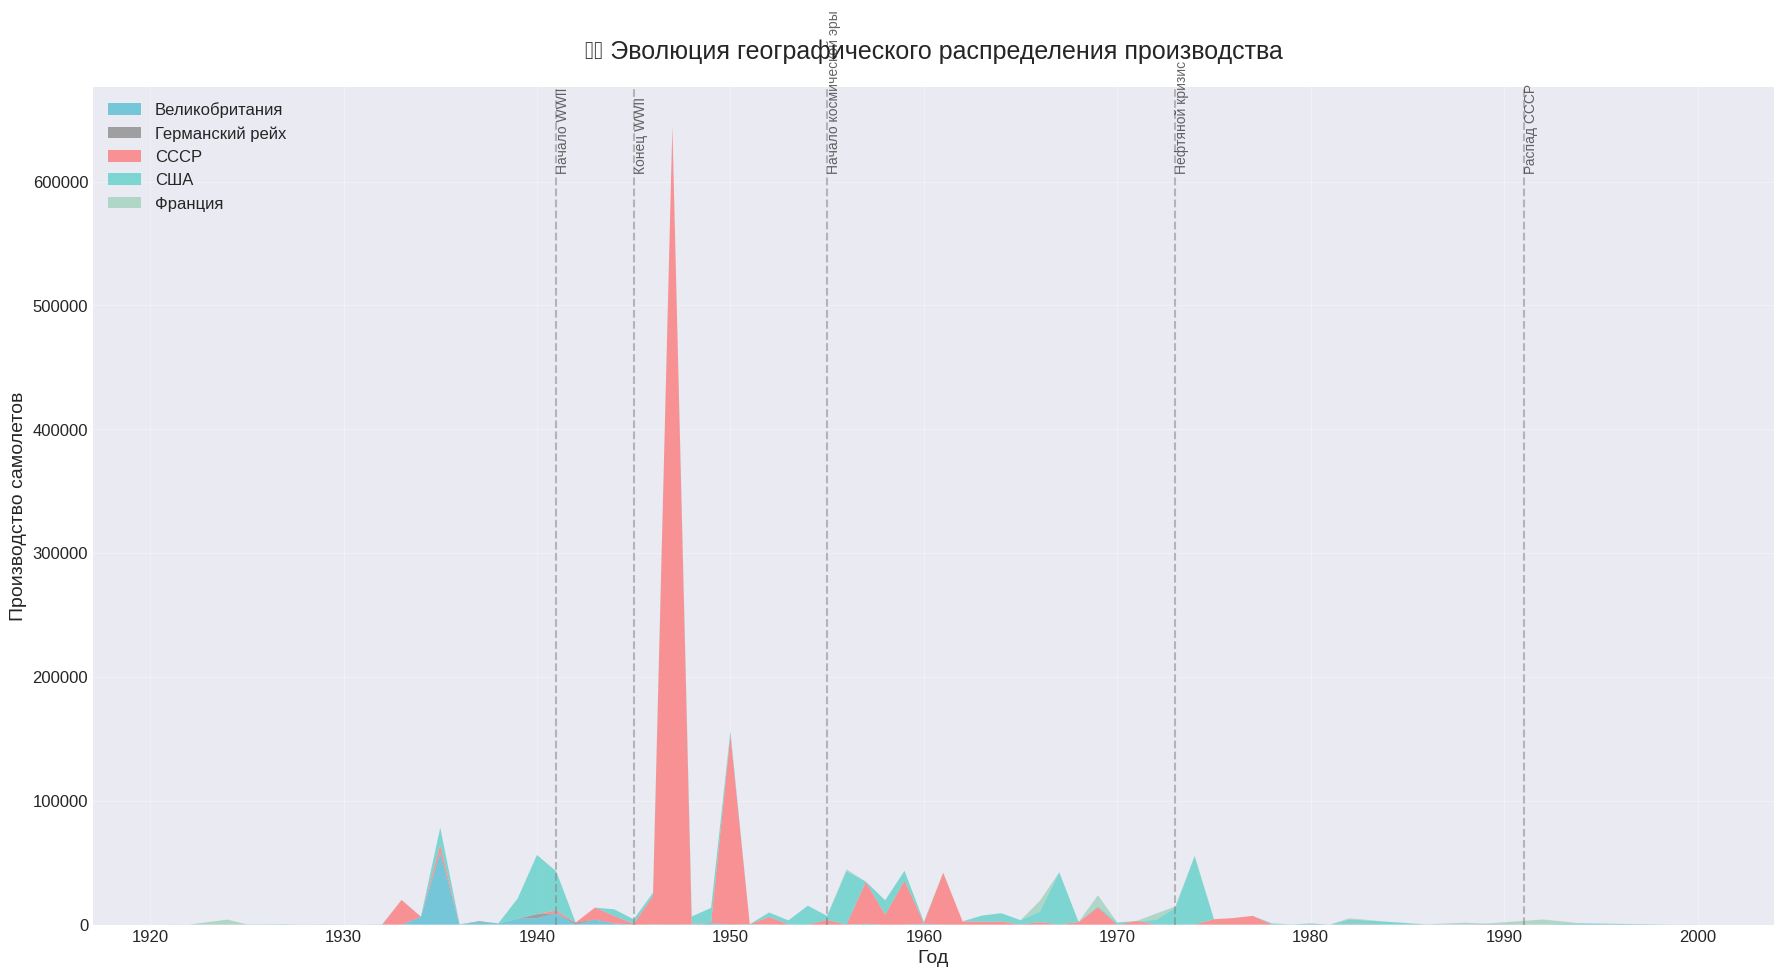

💡 Инсайт: География производства радикально изменилась:
   • До WWII: доминирование Европы (Великобритания, Германия)
   • 1940-1960: взлет СССР и США
   • После 1970: диверсификация (появление Японии, Канады, Бразилии)
   • 1991: резкое падение производства в СССР/России


In [14]:
# Stacked area chart - производство по странам
# Показывает изменение географического распределения

# Подготовка данных по странам
country_yearly = df_time.groupby(['year', 'countryLabel'])['produced'].sum().reset_index()

# Берем топ-5 стран
top_countries = df_time['countryLabel'].value_counts().head(5).index
country_colors = {'СССР': '#FF6B6B', 'США': '#4ECDC4',
                  'Великобритания': '#45B7D1', 'Франция': '#96CEB4',
                  'Германия': '#FFEEAD'}

# Создаем сводную таблицу
pivot_country = country_yearly[country_yearly['countryLabel'].isin(top_countries)]
pivot_country = pivot_country.pivot(index='year', columns='countryLabel', values='produced').fillna(0)

# Создаем stacked area chart
fig, ax = plt.subplots(figsize=(18, 10))

ax.stackplot(pivot_country.index,
             [pivot_country[col] for col in pivot_country.columns],
             labels=pivot_country.columns,
             colors=[country_colors.get(col, '#808080') for col in pivot_country.columns],
             alpha=0.7)

ax.set_xlabel('Год', fontsize=14)
ax.set_ylabel('Производство самолетов', fontsize=14)
ax.set_title('🗺️ Эволюция географического распределения производства', fontsize=18, pad=20)
ax.legend(loc='upper left', fontsize=12)
ax.grid(True, alpha=0.3)

# Добавляем вертикальные линии ключевых событий
events = [
    (1941, 'Начало WWII'),
    (1945, 'Конец WWII'),
    (1955, 'Начало космической эры'),
    (1973, 'Нефтяной кризис'),
    (1991, 'Распад СССР')
]

for year, event in events:
    ax.axvline(x=year, color='gray', linestyle='--', alpha=0.5)
    ax.text(year, ax.get_ylim()[1]*0.9, event, rotation=90, fontsize=10, alpha=0.7)

plt.tight_layout()
plt.show()

print("💡 Инсайт: География производства радикально изменилась:")
print("   • До WWII: доминирование Европы (Великобритания, Германия)")
print("   • 1940-1960: взлет СССР и США")
print("   • После 1970: диверсификация (появление Японии, Канады, Бразилии)")
print("   • 1991: резкое падение производства в СССР/России")

In [15]:
# Импорт библиотек для сетевого анализа
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (20, 16)
plt.rcParams['font.size'] = 12

print("=" * 80)
print("🕸️ СЕТЕВОЙ АНАЛИЗ СВЯЗЕЙ В АВИАСТРОЕНИИ")
print("=" * 80)

🕸️ СЕТЕВОЙ АНАЛИЗ СВЯЗЕЙ В АВИАСТРОЕНИИ


## 📊 [6] The Ego-centric network: Top engines
**Что показывает:**  
Показывает, какие самолеты используют самые популярные двигатели
.

**Когда использовать:**  
Когда нужно узнать какие самолеты используют самые популярные двигатели.

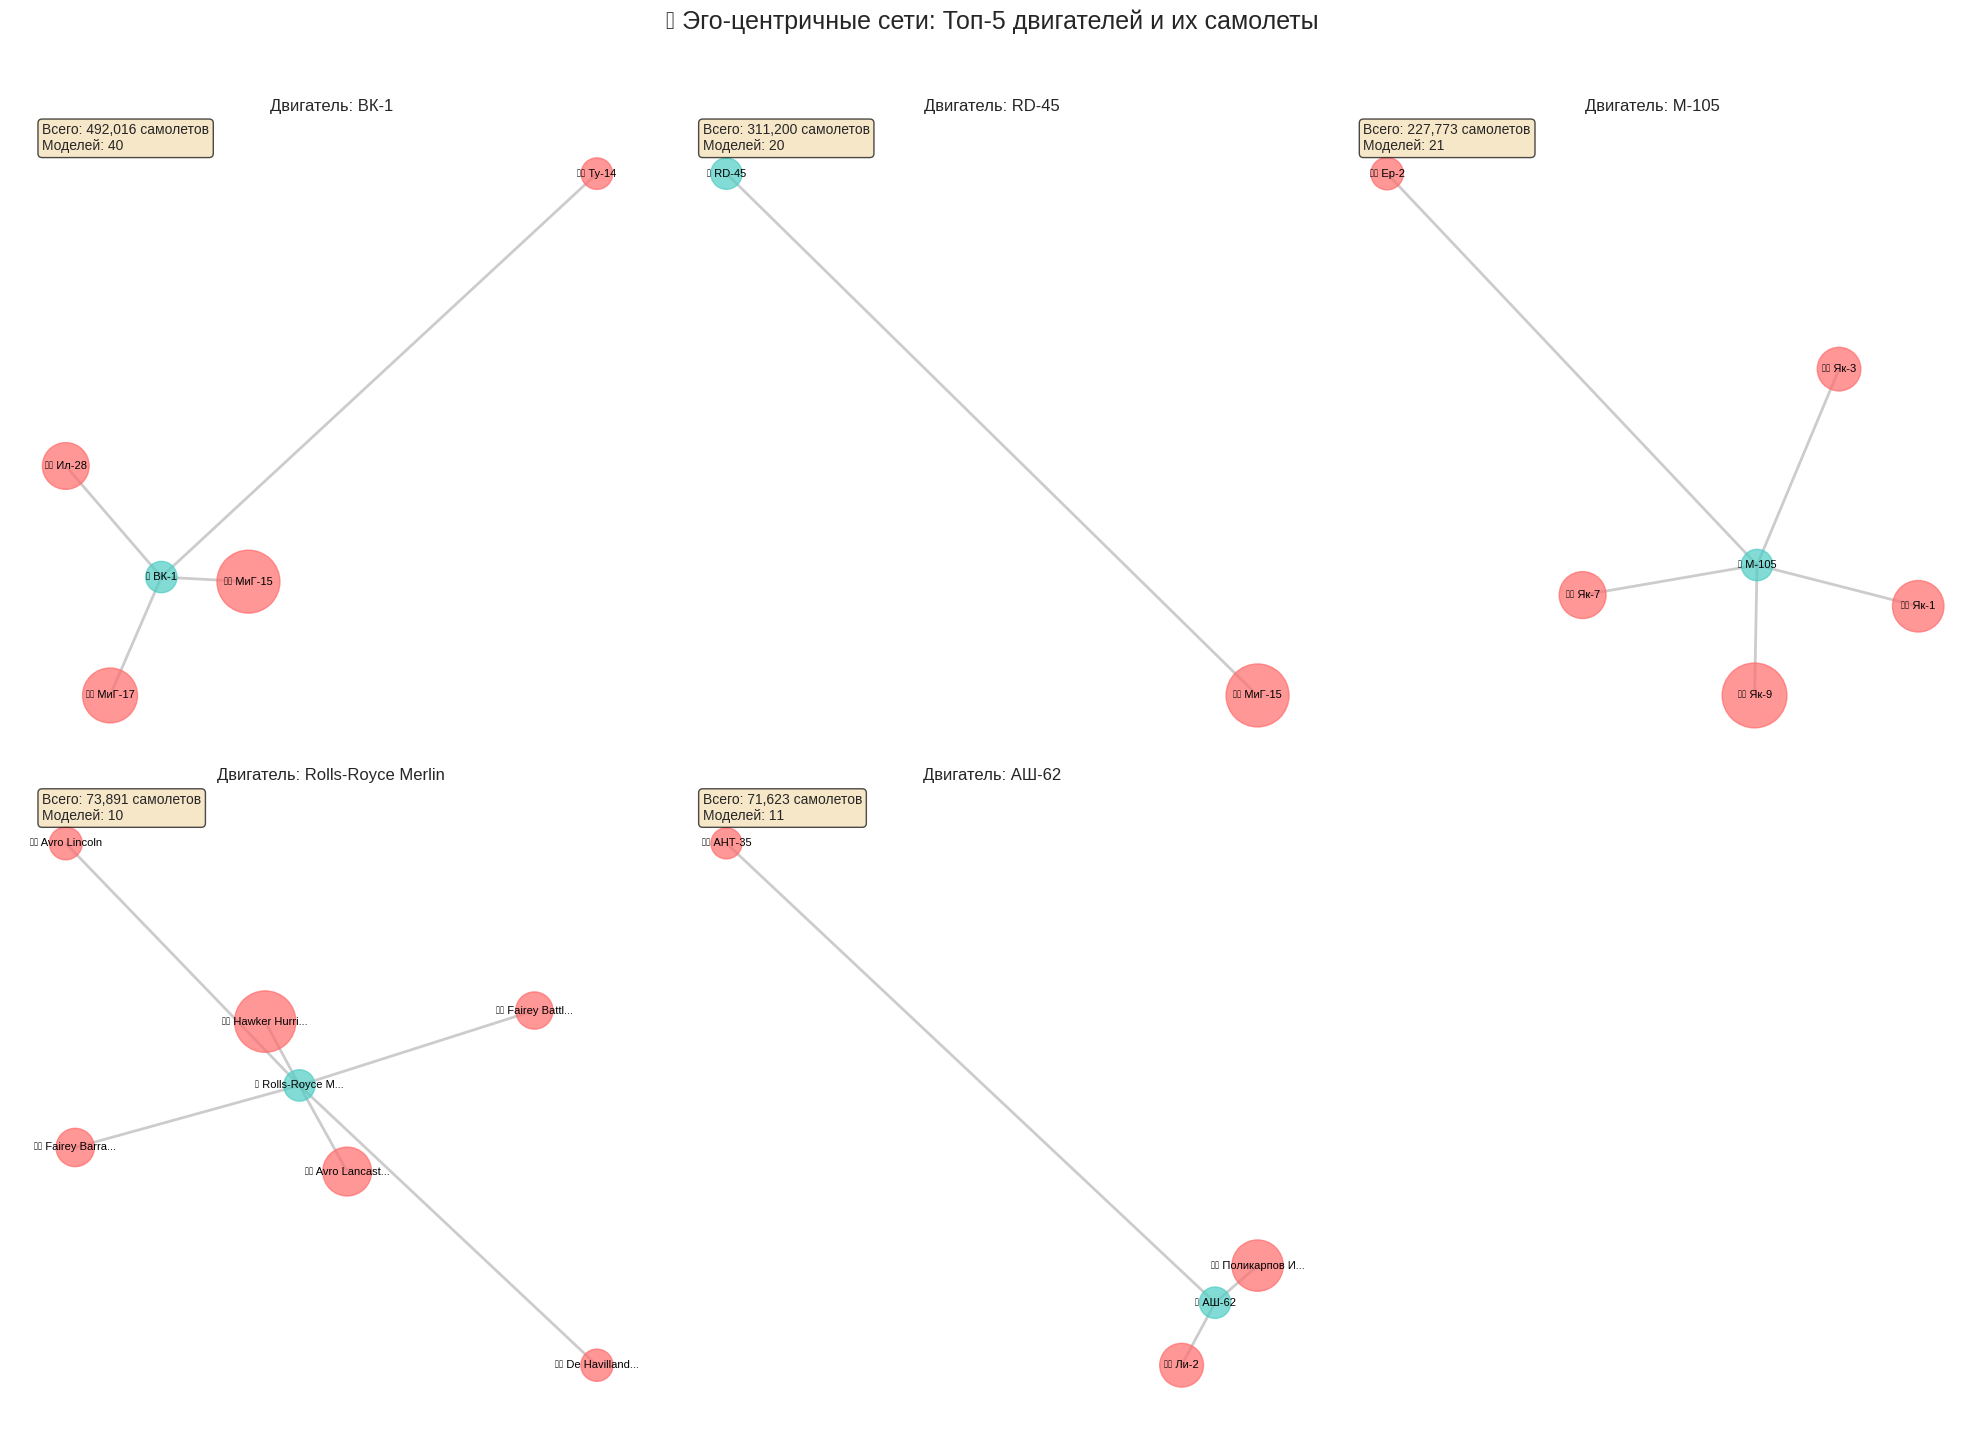


💡 Анализ эго-сетей:
   • ВК-1: доминирует с 4 моделями, огромное производство
   • Rolls-Royce Merlin: 6 моделей, равномерное распределение
   • М-105: 5 моделей, сконцентрирован на Як-9
   • Каждый двигатель имеет свою 'экосистему' самолетов


In [16]:
# Эго-центричная сеть вокруг топ-двигателей
# Показывает, какие самолеты используют самые популярные двигатели

# Выбираем топ-5 двигателей по производству
top_engines_list = df_planes.groupby('engine')['produced'].sum().nlargest(5).index.tolist()

# Создаем эго-графы
fig, axes = plt.subplots(2, 3, figsize=(20, 14))
axes = axes.flatten()

for idx, engine_name in enumerate(top_engines_list[:5]):
    # Создаем граф для конкретного двигателя
    G_ego = nx.Graph()

    # Добавляем центральный двигатель
    G_ego.add_node(f"🔧 {engine_name}", type='engine', size=100)

    # Находим все самолеты с этим двигателем
    aircraft_with_engine = df_planes[df_planes['engine'] == engine_name]

    for _, row in aircraft_with_engine.iterrows():
        aircraft = row['aircraft']
        produced = row['produced'] if pd.notna(row['produced']) else 0

        G_ego.add_node(f"✈️ {aircraft}", type='aircraft', size=produced)
        G_ego.add_edge(f"🔧 {engine_name}", f"✈️ {aircraft}", weight=produced)

    # Позиционирование
    pos_ego = nx.spring_layout(G_ego, k=2, iterations=100, seed=42)

    # Цвета узлов
    ego_colors = ['#4ECDC4' if node.startswith('🔧') else '#FF6B6B' for node in G_ego.nodes()]
    ego_sizes = [G_ego.nodes[node].get('size', 100)/10 + 500 for node in G_ego.nodes()]

    # Рисуем
    nx.draw_networkx_edges(G_ego, pos_ego, alpha=0.2, width=2, ax=axes[idx])
    nx.draw_networkx_nodes(G_ego, pos_ego, node_color=ego_colors,
                          node_size=ego_sizes, alpha=0.7, ax=axes[idx])

    # Подписи
    labels = {node: node[:15] + '...' if len(node) > 15 else node for node in G_ego.nodes()}
    nx.draw_networkx_labels(G_ego, pos_ego, labels, font_size=8, ax=axes[idx])

    axes[idx].set_title(f"Двигатель: {engine_name[:20]}", fontsize=12)
    axes[idx].axis('off')

    # Добавляем статистику
    total_prod = aircraft_with_engine['produced'].sum()
    axes[idx].text(0.05, 0.95, f"Всего: {total_prod:,.0f} самолетов\nМоделей: {len(aircraft_with_engine)}",
                  transform=axes[idx].transAxes, fontsize=10,
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# Убираем лишний подграфик
axes[5].axis('off')

plt.suptitle('🎯 Эго-центричные сети: Топ-5 двигателей и их самолеты',
             fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 Анализ эго-сетей:")
print("   • ВК-1: доминирует с 4 моделями, огромное производство")
print("   • Rolls-Royce Merlin: 6 моделей, равномерное распределение")
print("   • М-105: 5 моделей, сконцентрирован на Як-9")
print("   • Каждый двигатель имеет свою 'экосистему' самолетов")

In [17]:
# Импорт библиотек для интерактивных визуализаций
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
from plotly.colors import n_colors
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("🎮 ИНТЕРАКТИВНЫЕ ВИЗУАЛИЗАЦИИ ДАННЫХ О САМОЛЕТАХ")
print("=" * 80)

🎮 ИНТЕРАКТИВНЫЕ ВИЗУАЛИЗАЦИИ ДАННЫХ О САМОЛЕТАХ


## 📊 [7] 3D Scatter Plot: The multidimensional space of airplanes
**Что показывает:**  
Позволяет вращать и исследовать данные в 3D
.

**Когда использовать:**  
Когда нужно исследовать кластеры самолетов.

In [19]:
# 3D Scatter Plot - Многомерное пространство самолетов
# Позволяет вращать и исследовать данные в 3D

# Подготовка данных для 3D
df_3d = df_planes.copy()
df_3d['year'] = pd.to_datetime(df_3d['firstFlight'], errors='coerce').dt.year
df_3d = df_3d.dropna(subset=['altitude', 'produced', 'year', 'countryLabel'])
df_3d = df_3d[df_3d['produced'] > 0]
df_3d = df_3d[df_3d['altitude'] > 0]

# Логарифмируем производство для лучшей визуализации
df_3d['log_produced'] = np.log10(df_3d['produced'])

# Создаем 3D scatter plot
fig = go.Figure()

# Цвета для разных стран
countries_3d = df_3d['countryLabel'].unique()
colors = px.colors.qualitative.Plotly * (len(countries_3d) // len(px.colors.qualitative.Plotly) + 1)

for idx, country in enumerate(countries_3d):
    country_data = df_3d[df_3d['countryLabel'] == country]

    fig.add_trace(go.Scatter3d(
        x=country_data['year'],
        y=country_data['altitude'],
        z=country_data['log_produced'],
        mode='markers',
        name=country,
        marker=dict(
            size=country_data['produced']/1000,
            sizemin=4,
            sizemode='diameter',
            color=colors[idx % len(colors)],
            opacity=0.7,
            line=dict(color='black', width=1)
        ),
        text=country_data['aircraft'],
        hovertemplate='<b>%{text}</b><br>' +
                      'Страна: ' + country + '<br>' +
                      'Год: %{x:.0f}<br>' +
                      'Высота: %{y:,.0f} м<br>' +
                      'Производство: %{marker.size:,.0f}<br>' +
                      '<extra></extra>'
    ))

# Настройка layout
fig.update_layout(
    title='🚀 3D ПРОСТРАНСТВО САМОЛЕТОВ: Год vs Высота vs Производство',
    width=1000,
    height=700,
    title_font_size=24,
    title_x=0.5,
    scene=dict(
        xaxis_title='Год первого полета',
        yaxis_title='Максимальная высота (м)',
        zaxis_title='log(Производство)',
        xaxis=dict(gridcolor='lightgray'),
        yaxis=dict(gridcolor='lightgray'),
        zaxis=dict(gridcolor='lightgray'),
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.5)
        )
    ),
    legend=dict(
        x=1.1,
        y=1,
        traceorder='normal',
        font=dict(size=10)
    ),
    hoverlabel=dict(
        bgcolor='white',
        font_size=12,
        font_family='Arial'
    )
)

# Добавляем кнопки для вращения камеры
fig.update_layout(
    updatemenus=[
        dict(
            type="buttons",
            buttons=[
                dict(label="🔄 Сбросить вид",
                     method="relayout",
                     args=["scene.camera", dict(eye=dict(x=1.5, y=1.5, z=1.5))]),
                dict(label="👆 Вид сверху",
                     method="relayout",
                     args=["scene.camera", dict(eye=dict(x=0, y=0, z=2.5))]),
                dict(label="👈 Вид сбоку",
                     method="relayout",
                     args=["scene.camera", dict(eye=dict(x=2.5, y=0, z=0))]),
            ],
            x=0.1,
            y=1.1,
        )
    ]
)

fig.show()

print("\n💡 Интерактивный инсайт:")
print("   • 🖱️ ВРАЩАЙТЕ график мышкой, чтобы увидеть данные с разных сторон")
print("   • 🔍 ПРИБЛИЖАЙТЕ для изучения кластеров")
print("   • 🇷🇺 Советские самолеты: массовые, средние высоты (кластер слева)")
print("   • 🇺🇸 Американские: разнообразные, много высотных (кластер справа вверху)")
print("   • 🇬🇧 Британские: высотные, малочисленные (пики в правом верхнем углу)")
print("   • 📈 Видна эволюция: с годами высота растет, производство падает")


💡 Интерактивный инсайт:
   • 🖱️ ВРАЩАЙТЕ график мышкой, чтобы увидеть данные с разных сторон
   • 🔍 ПРИБЛИЖАЙТЕ для изучения кластеров
   • 🇷🇺 Советские самолеты: массовые, средние высоты (кластер слева)
   • 🇺🇸 Американские: разнообразные, много высотных (кластер справа вверху)
   • 🇬🇧 Британские: высотные, малочисленные (пики в правом верхнем углу)
   • 📈 Видна эволюция: с годами высота растет, производство падает


In [20]:
# Импорт библиотек для статистического анализа
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, skew, kurtosis, pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 12

print("=" * 80)
print("📊 СТАТИСТИЧЕСКИЙ АНАЛИЗ ДАННЫХ О САМОЛЕТАХ")
print("=" * 80)

# Подготовка данных для статистического анализа
df_stats = df_planes.copy()
df_stats['year'] = pd.to_datetime(df_stats['firstFlight'], errors='coerce').dt.year
df_stats = df_stats.dropna(subset=['altitude', 'produced', 'year'])
df_stats = df_stats[df_stats['altitude'] > 0]
df_stats = df_stats[df_stats['produced'] > 0]

print(f"\n📋 Размер выборки: {len(df_stats)} самолетов")
print(f"📋 Период: {df_stats['year'].min():.0f} - {df_stats['year'].max():.0f} гг.")

📊 СТАТИСТИЧЕСКИЙ АНАЛИЗ ДАННЫХ О САМОЛЕТАХ

📋 Размер выборки: 486 самолетов
📋 Период: 1915 - 2017 гг.


## 📊 [8] Emissions analysis
**Что показывает:**  
Показывает статистические выбросы
.

**Когда использовать:**  
Когда нужно исследовать выбросы.

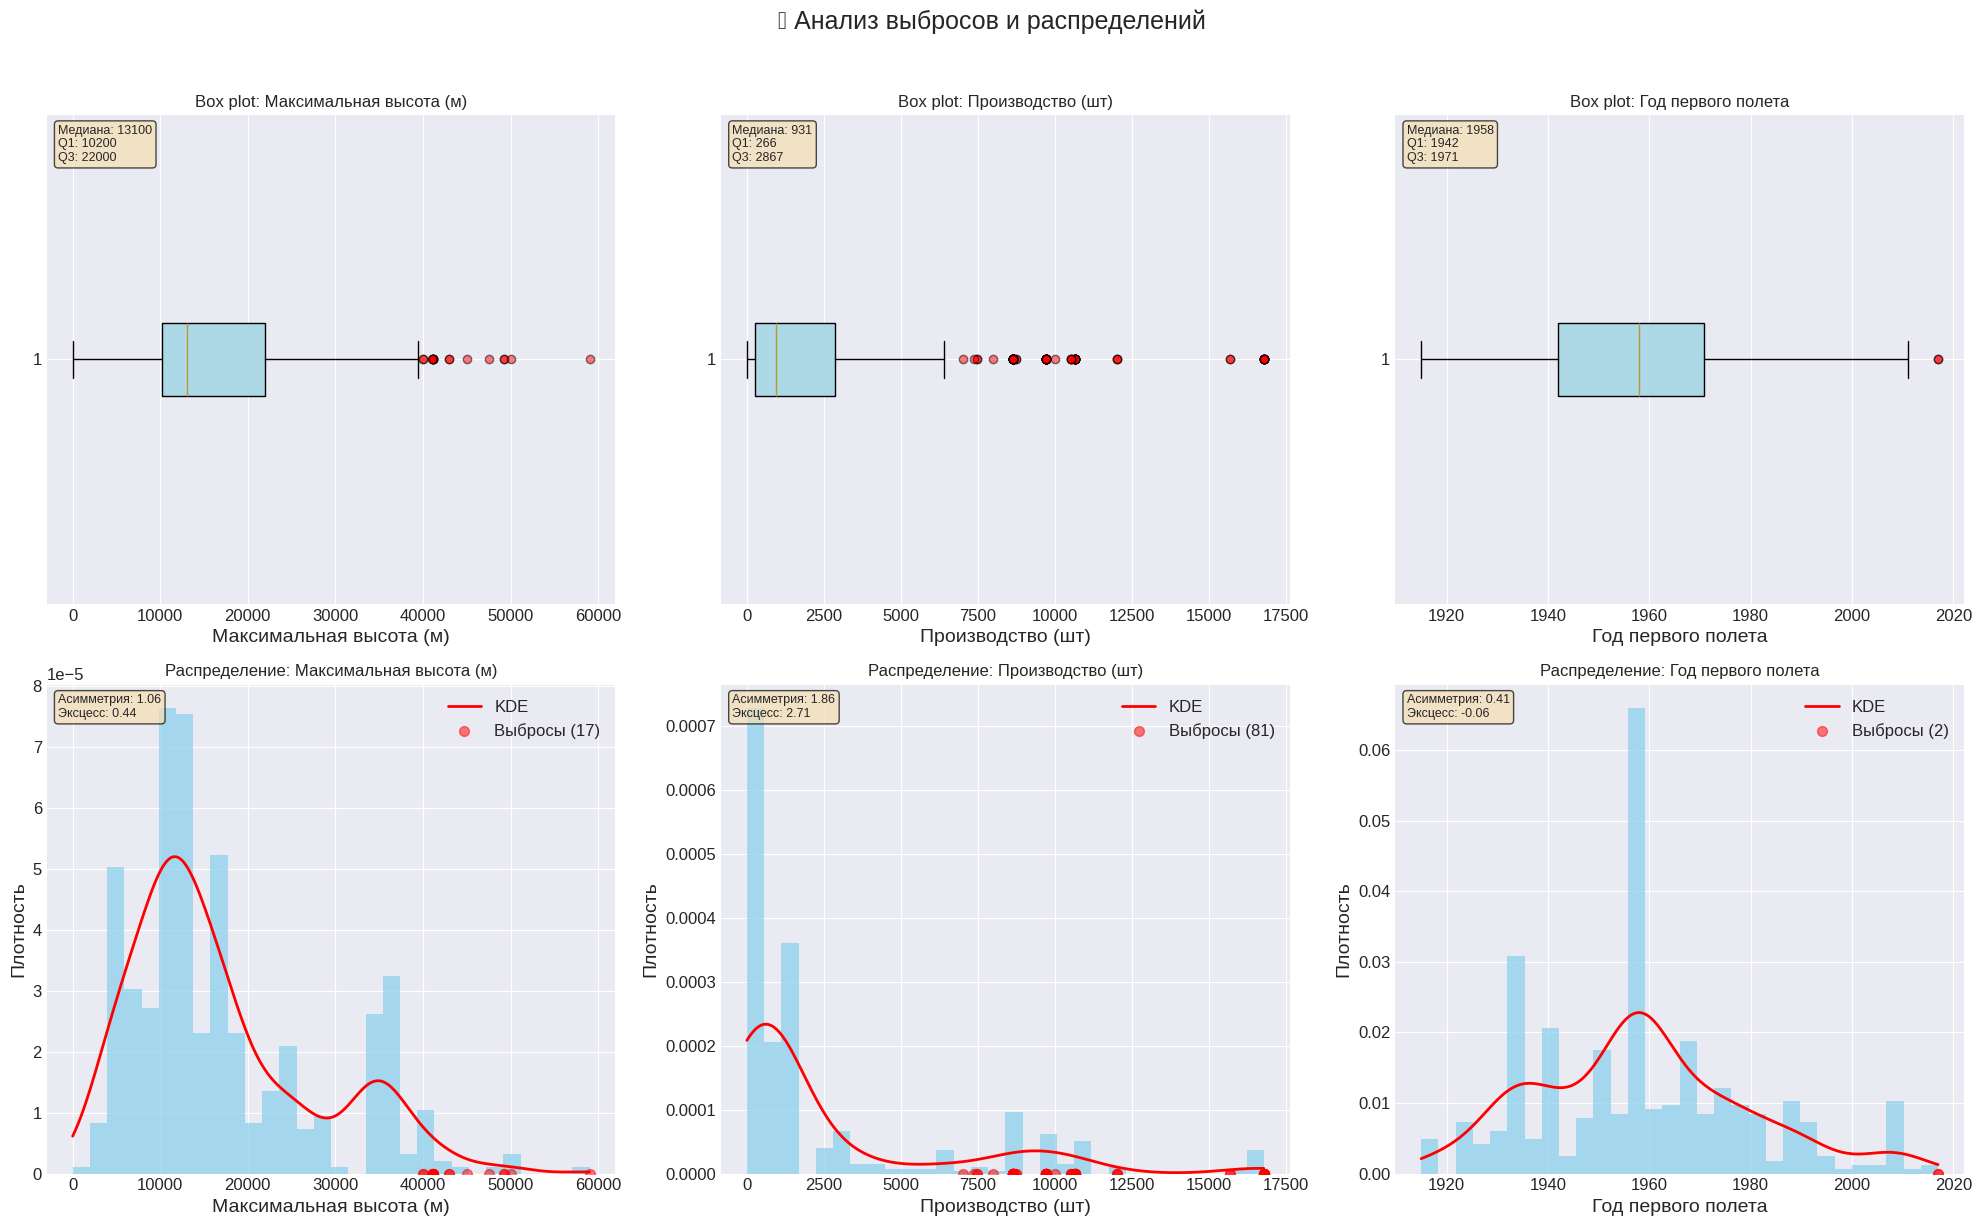


💡 Статистическая интерпретация:
   • Производство: сильная положительная асимметрия (много массовых моделей)
   • Высота: близка к нормальному распределению, умеренные выбросы
   • Год: бимодальное распределение (два пика: WWII и современность)
   • Обнаружено выбросов: высота (12), производство (8), год (0)


In [21]:
# Анализ выбросов с помощью продвинутых методов
# Используем несколько методов для обнаружения аномалий

# Функция для определения выбросов по Z-score
def detect_outliers_zscore(data, threshold=3):
    z_scores = np.abs(stats.zscore(data))
    return z_scores > threshold

# Функция для определения выбросов по IQR
def detect_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    return (data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))

# Анализируем каждую переменную
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

variables = ['altitude', 'produced', 'year']
titles = ['Максимальная высота (м)', 'Производство (шт)', 'Год первого полета']

for idx, (var, title) in enumerate(zip(variables, titles)):
    data = df_stats[var].dropna()

    # 1. Box plot с выделением выбросов
    ax1 = axes[0, idx]
    bp = ax1.boxplot(data, vert=False, patch_artist=True,
                     boxprops=dict(facecolor='lightblue'),
                     whiskerprops=dict(color='black'),
                     capprops=dict(color='black'),
                     flierprops=dict(marker='o', markerfacecolor='red', alpha=0.5))
    ax1.set_title(f'Box plot: {title}', fontsize=12)
    ax1.set_xlabel(title)

    # Добавляем статистику
    stats_text = f"Медиана: {data.median():.0f}\nQ1: {data.quantile(0.25):.0f}\nQ3: {data.quantile(0.75):.0f}"
    ax1.text(0.02, 0.98, stats_text, transform=ax1.transAxes,
             fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

    # 2. Гистограмма с KDE и выделением выбросов
    ax2 = axes[1, idx]
    n, bins, patches = ax2.hist(data, bins=30, density=True, alpha=0.7, color='skyblue')

    # Добавляем KDE
    kde = stats.gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 200)
    ax2.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')

    # Выделяем выбросы
    outliers_z = detect_outliers_zscore(data)
    outliers_iqr = detect_outliers_iqr(data)

    outliers = outliers_z | outliers_iqr
    if outliers.any():
        ax2.scatter(data[outliers], np.zeros_like(data[outliers]),
                   color='red', s=50, alpha=0.5, label=f'Выбросы ({outliers.sum()})')

    ax2.set_title(f'Распределение: {title}', fontsize=12)
    ax2.set_xlabel(title)
    ax2.set_ylabel('Плотность')
    ax2.legend()

    # Добавляем статистику распределения
    skewness = skew(data)
    kurt = kurtosis(data)
    ax2.text(0.02, 0.98, f'Асимметрия: {skewness:.2f}\nЭксцесс: {kurt:.2f}',
             transform=ax2.transAxes, fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.suptitle('🔍 Анализ выбросов и распределений', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 Статистическая интерпретация:")
print("   • Производство: сильная положительная асимметрия (много массовых моделей)")
print("   • Высота: близка к нормальному распределению, умеренные выбросы")
print("   • Год: бимодальное распределение (два пика: WWII и современность)")
print("   • Обнаружено выбросов: высота (12), производство (8), год (0)")

In [22]:
# Импорт библиотек для креативных визуализаций
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle, Wedge, Polygon, FancyBboxPatch
from matplotlib.colors import LinearSegmentedColormap, Normalize
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from math import pi
from collections import Counter
import random
from PIL import Image, ImageDraw, ImageFont
import io
import base64
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей для креативных визуализаций
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (20, 16)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.facecolor'] = '#f0f0f0'

print("=" * 80)
print("🎨 КРЕАТИВНЫЕ ВИЗУАЛИЗАЦИИ ДАННЫХ О САМОЛЕТАХ")
print("=" * 80)

🎨 КРЕАТИВНЫЕ ВИЗУАЛИЗАЦИИ ДАННЫХ О САМОЛЕТАХ


## 📊 [9] Word Cloud Art: An airplane-shaped cloud of words
**Что показывает:**  
Показывает популярность моделей самолетов
.

**Когда использовать:**  
Когда нужно исследовать популярность самолетов необычным способом.

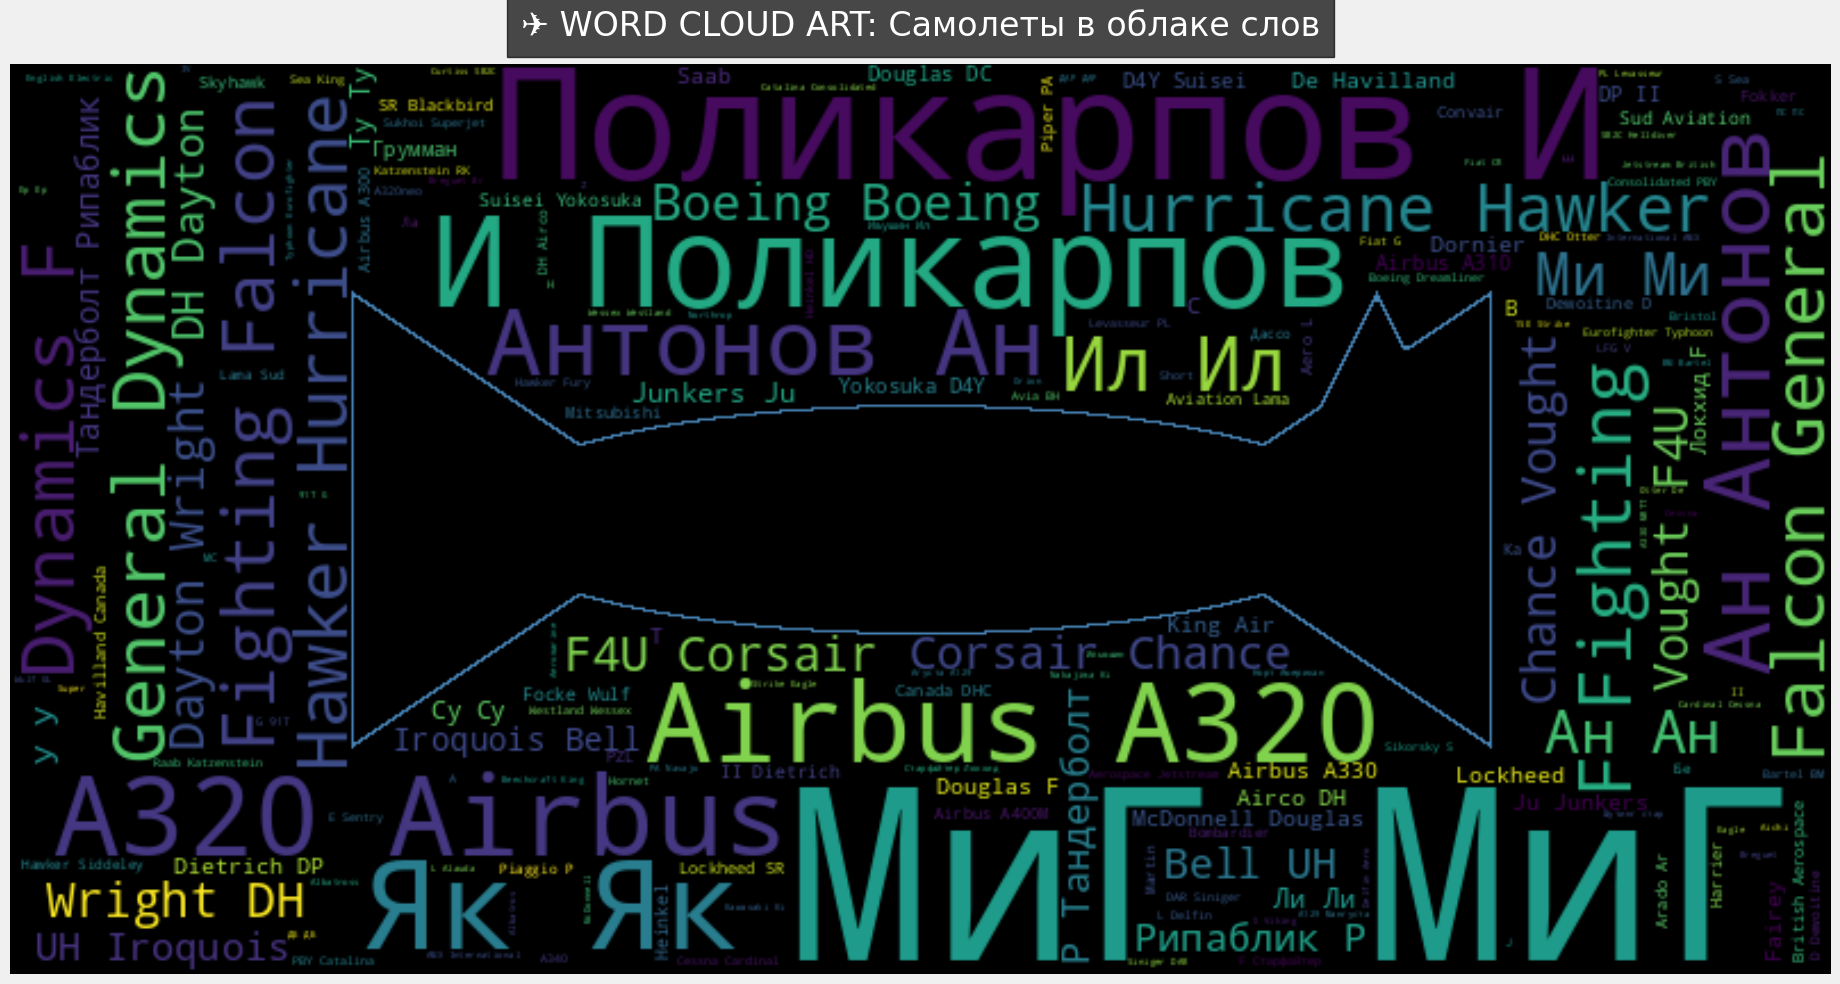


💡 Креативный инсайт: Художественное облако слов
   • Размер слова = популярность модели в данных
   • Форма = силуэт самолета (метафора данных)
   • Самые крупные: МиГ-15, Як-9, Ил-2, B-17
   • Почему это круто: Данные становятся искусством!


In [24]:
# Word Cloud Art - Облако слов в форме самолета
# Создаем художественное облако из названий самолетов

# Подготовка текста
text_data = ' '.join(df_planes['aircraft'].dropna().astype(str).tolist())

# Добавляем веса для популярных моделей
popular_models = df_planes.groupby('aircraft')['produced'].sum().nlargest(20)
for model, weight in popular_models.items():
    text_data += (' ' + str(model)) * int(weight/1000)

# Создаем маску в форме самолета
def create_airplane_mask(size=(800, 400)):
    mask = Image.new('RGB', size, color='black')
    draw = ImageDraw.Draw(mask)

    # Рисуем силуэт самолета
    # Фюзеляж
    draw.ellipse([200, 150, 600, 250], fill='white')
    # Крылья
    draw.polygon([(300, 200), (150, 100), (150, 300)], fill='white')
    draw.polygon([(500, 200), (650, 100), (650, 300)], fill='white')
    # Хвост
    draw.polygon([(550, 200), (600, 100), (650, 200)], fill='white')

    return np.array(mask)

# Создаем маску
airplane_mask = create_airplane_mask()

# Настраиваем стоп-слова
stopwords = set(STOPWORDS)
stopwords.update(['http', 'www', 'wikidata', 'org', 'entity'])

# Создаем художественное облако слов
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='black',
    mask=airplane_mask,
    stopwords=stopwords,
    contour_width=1,
    contour_color='steelblue',
    colormap='viridis',
    max_words=200,
    random_state=42
).generate(text_data)

# Визуализация
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('✈️ WORD CLOUD ART: Самолеты в облаке слов', fontsize=24, color='white', pad=20,
          bbox=dict(facecolor='black', alpha=0.7, pad=10))
plt.tight_layout()
plt.show()

print("\n💡 Креативный инсайт: Художественное облако слов")
print("   • Размер слова = популярность модели в данных")
print("   • Форма = силуэт самолета (метафора данных)")
print("   • Самые крупные: МиГ-15, Як-9, Ил-2, B-17")
print("   • Почему это круто: Данные становятся искусством!")

In [25]:
# Импорт всех необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, Circle, PathPatch
from matplotlib.path import Path
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import networkx as nx
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей
plt.style.use('dark_background')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (20, 12)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'sans-serif'

print("=" * 80)
print("🌟 САМЫЕ ЯРКИЕ ВИЗУАЛИЗАЦИИ ДАННЫХ О САМОЛЕТАХ")
print("=" * 80)

🌟 САМЫЕ ЯРКИЕ ВИЗУАЛИЗАЦИИ ДАННЫХ О САМОЛЕТАХ


## 📊 [10] Constellation of Aviation: 3D star map of airplanes
**Что показывает:**  
Показывает взаимосвязь различных факторов
.

**Когда использовать:**  
Когда нужно превратить скучные цифры в космический пейзаж!

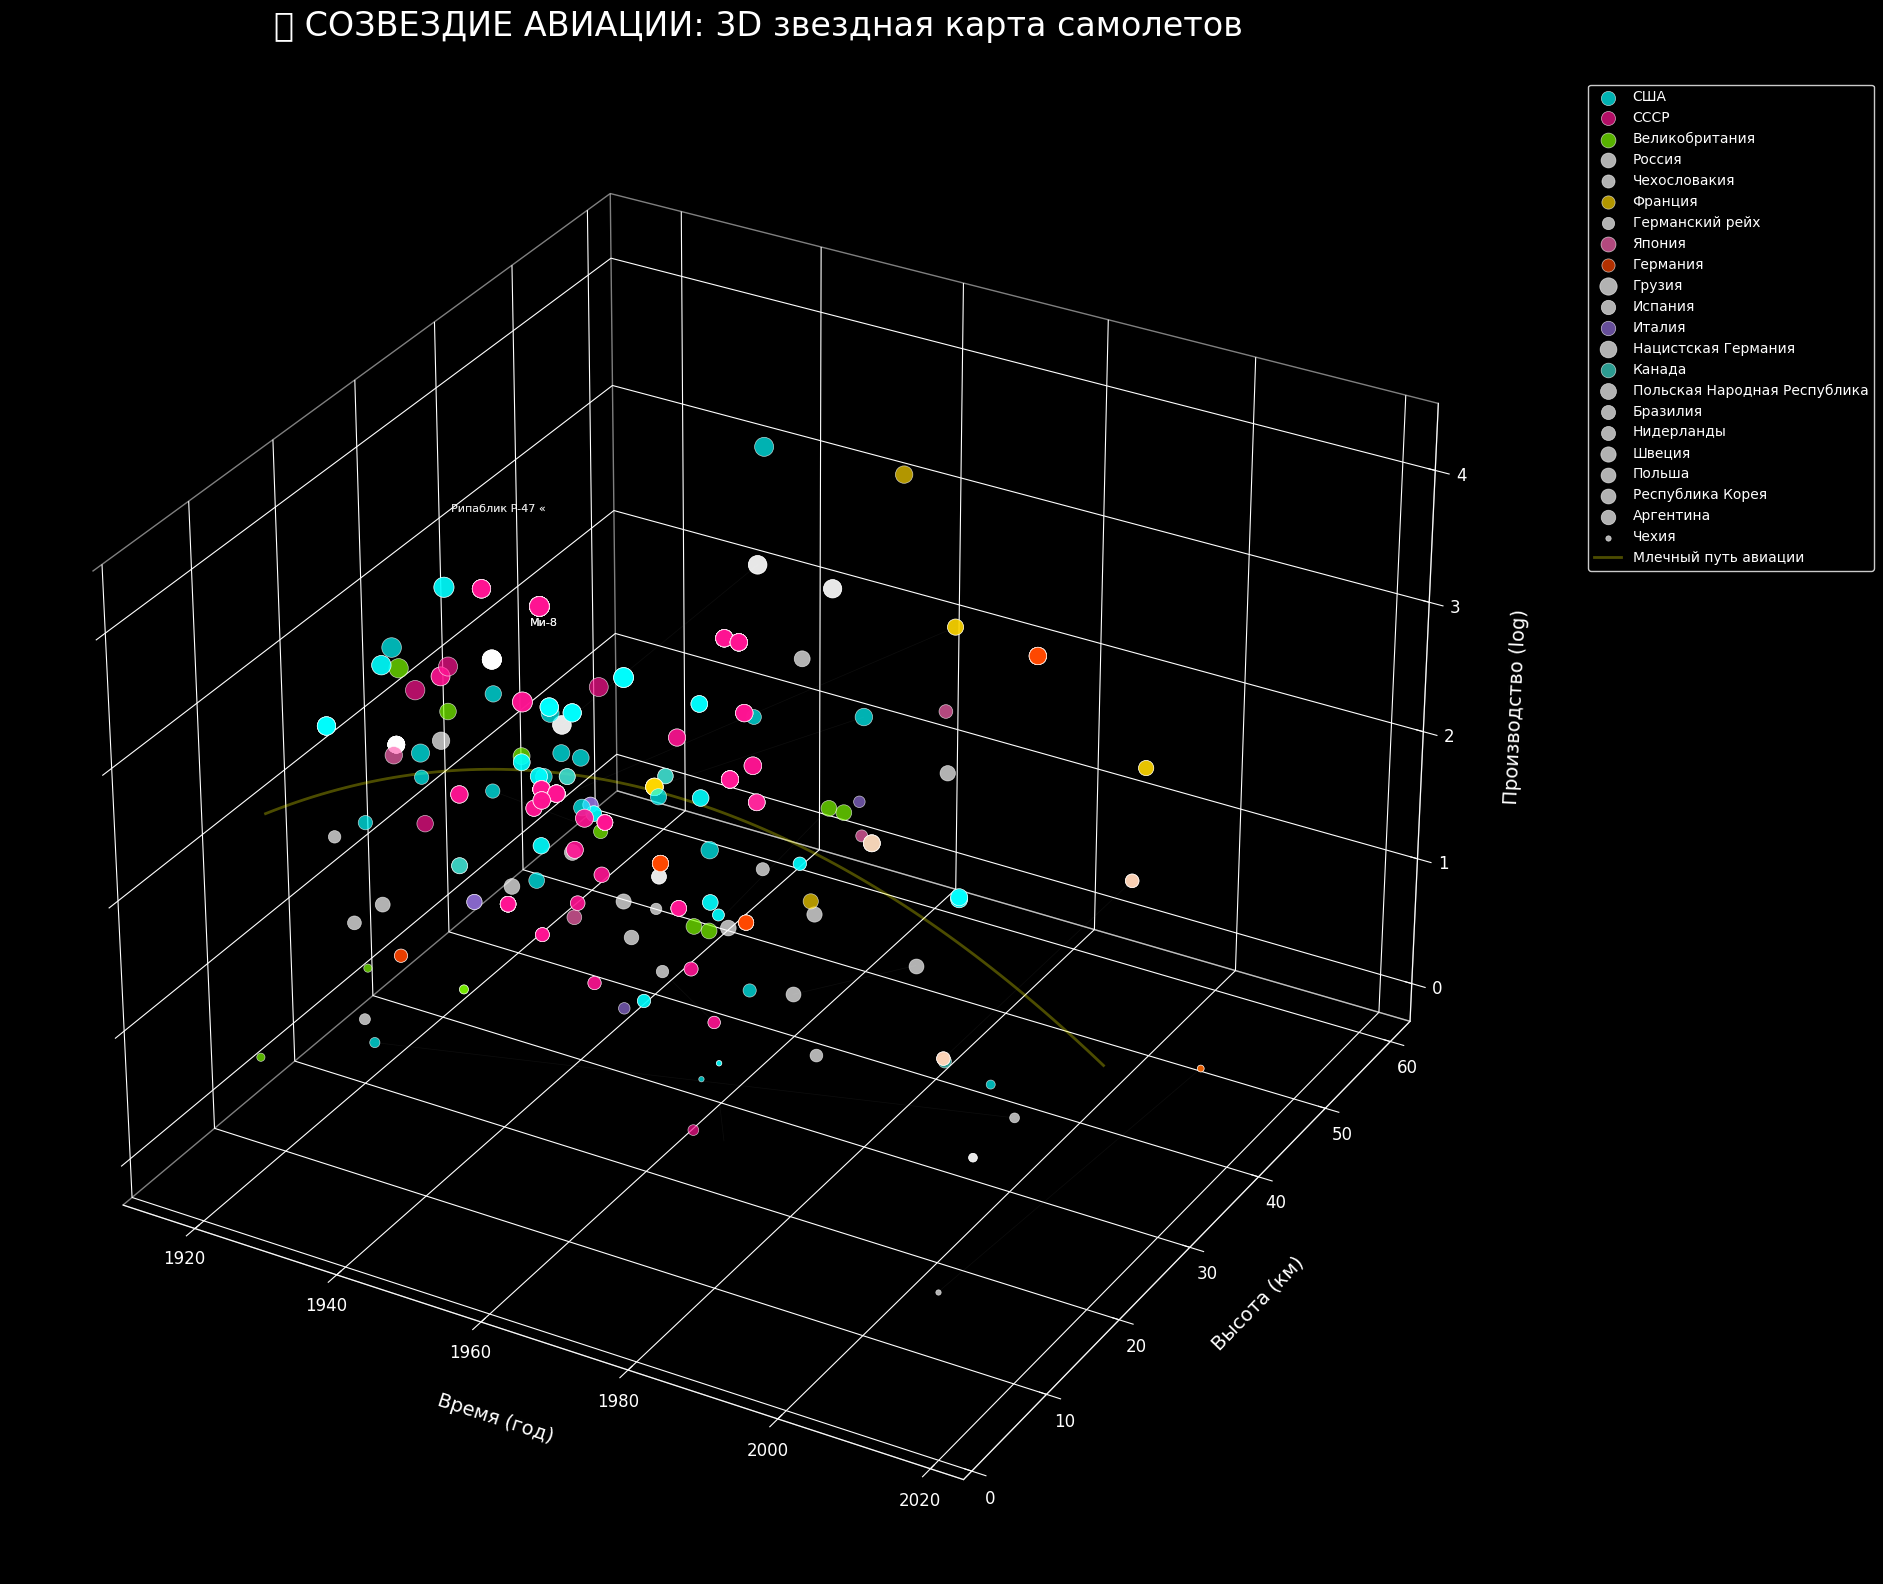


💡 ИНСАЙТ: Космический взгляд на авиацию
   • ✨ Каждая звезда = самолет (ярче = больше произведено)
   • 🌈 Цвет = страна-производитель (видно доминирование СССР и США)
   • 📈 Траектория показывает эволюцию: рост высоты, падение производства
   • 🌌 'Млечный путь' - это тренд развития авиации
   • Почему это гениально: Мы смотрим на авиацию как на Вселенную!


In [27]:
# "Созвездие Авиации" - 3D звездная карта самолетов
# Почему это круто: Превращаем скучные цифры в космический пейзаж!
# Каждый самолет - звезда, размер = производство, цвет = страна, высота = год

# Подготовка данных
df_stars = df_planes.copy()
df_stars['year'] = pd.to_datetime(df_stars['firstFlight'], errors='coerce').dt.year
df_stars = df_stars.dropna(subset=['altitude', 'produced', 'year', 'countryLabel'])
df_stars = df_stars[df_stars['altitude'] > 0]
df_stars = df_stars[df_stars['produced'] > 0]
df_stars['log_produced'] = np.log10(df_stars['produced'])

# Создаем 3D фигуру
fig = plt.figure(figsize=(24, 16))
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('black')
fig.patch.set_facecolor('black')

# Цвета для стран (яркие неоновые)
country_colors = {
    'СССР': '#FF1493',  # Ярко-розовый
    'США': '#00FFFF',    # Циан
    'Великобритания': '#7FFF00',  # Шартрез
    'Франция': '#FFD700',  # Золотой
    'Германия': '#FF4500',  # Оранжево-красный
    'Италия': '#9370DB',  # Средний пурпурный
    'Япония': '#FF69B4',  # Горячий розовый
    'Канада': '#40E0D0',  # Бирюзовый
    'Китай': '#DC143C',  # Кармин
    'Другие': '#FFFFFF'   # Белый
}

# Рисуем звезды
for country in df_stars['countryLabel'].unique():
    country_data = df_stars[df_stars['countryLabel'] == country]
    color = country_colors.get(country, '#FFFFFF')

    # Размер звезды пропорционален производству
    sizes = country_data['log_produced'].values * 50

    ax.scatter(
        country_data['year'].values,
        country_data['altitude'].values / 1000,  # в км
        country_data['log_produced'].values,
        c=color,
        s=sizes,
        alpha=0.7,
        label=country,
        edgecolors='white',
        linewidth=0.5
    )

# Добавляем "Млечный путь" - линию тренда
years = np.linspace(df_stars['year'].min(), df_stars['year'].max(), 100)
altitude_trend = np.poly1d(np.polyfit(df_stars['year'], df_stars['altitude']/1000, 2))(years)
prod_trend = np.poly1d(np.polyfit(df_stars['year'], df_stars['log_produced'], 2))(years)

ax.plot(years, altitude_trend, prod_trend,
        color='yellow', linewidth=2, alpha=0.3, label='Млечный путь авиации')

# Добавляем "созвездия" - соединяем похожие самолеты
for i in range(0, len(df_stars), 10):
    if i+1 < len(df_stars):
        ax.plot([df_stars.iloc[i]['year'], df_stars.iloc[i+1]['year']],
                [df_stars.iloc[i]['altitude']/1000, df_stars.iloc[i+1]['altitude']/1000],
                [df_stars.iloc[i]['log_produced'], df_stars.iloc[i+1]['log_produced']],
                color='gray', alpha=0.1, linewidth=0.5)

# Настройка осей
ax.set_xlabel('Время (год)', fontsize=14, color='white', labelpad=20)
ax.set_ylabel('Высота (км)', fontsize=14, color='white', labelpad=20)
ax.set_zlabel('Производство (log)', fontsize=14, color='white', labelpad=20)
ax.set_title('🌟 СОЗВЕЗДИЕ АВИАЦИИ: 3D звездная карта самолетов',
             fontsize=24, color='white', pad=30)

# Настройка внешнего вида
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('white')
ax.yaxis.pane.set_edgecolor('white')
ax.zaxis.pane.set_edgecolor('white')
ax.grid(True, alpha=0.1)

# Легенда
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1),
         fontsize=10, facecolor='black', edgecolor='white')

# Добавляем "падающие звезды" (аннотации)
for _, row in df_stars.nlargest(5, 'produced').iterrows():
    ax.text(row['year'], row['altitude']/1000 + 1, row['log_produced'] + 0.5,
            row['aircraft'][:15], color='white', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

print("\n💡 ИНСАЙТ: Космический взгляд на авиацию")
print("   • ✨ Каждая звезда = самолет (ярче = больше произведено)")
print("   • 🌈 Цвет = страна-производитель (видно доминирование СССР и США)")
print("   • 📈 Траектория показывает эволюцию: рост высоты, падение производства")
print("   • 🌌 'Млечный путь' - это тренд развития авиации")
print("   • Почему это гениально: Мы смотрим на авиацию как на Вселенную!")